In [429]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

In [430]:
data = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
data.data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [431]:
X = data.data
X = X / 255.0
y = data.target

In [432]:
def display_image(index, X, y):
    print(f'\nLabel: {y[index]}\n')
    image = X[index].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.show()


Label: 4



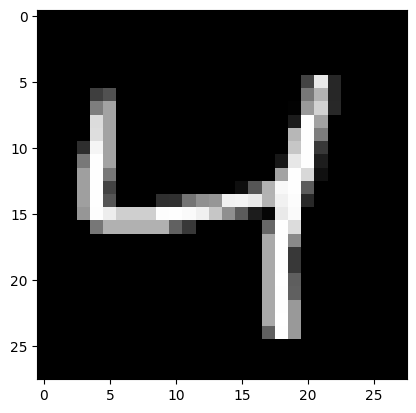

In [433]:
display_image(2, X, y)

In [434]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self, output_gradient, learning_rate, batch_size):
        pass

In [479]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size
        self.weights = np.random.randn(self.output_size, self.input_size) * np.sqrt(2 / input_size)
        self.baises = np.zeros((self.output_size, 1))

    def forward(self, input):
        self.input = input
        return self.weights @ self.input + self.baises
        

    def backward(self, output_gradient, learning_rate):
        batch_size = output_gradient.shape[1]

        dW = output_gradient @ self.input.T / batch_size
        dB = np.sum(output_gradient, axis=1, keepdims=True) / batch_size
        dX = self.weights.T @ output_gradient
    
        self.weights -= learning_rate * dW
        self.baises  -= learning_rate * dB
    
        return dX

In [480]:
class Activation(Layer):
    def __init__(self, activation_function, activation_prime):
        self.activation_function = activation_function
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation_function(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [481]:
class Tanh(Activation):
    def __init__(self):
        tanh = lambda x: np.tanh(x)
        tanh_prime = lambda x: 1 - np.tanh(x)**2
        super().__init__(tanh, tanh_prime)

In [482]:
class ReLU(Activation):
    def __init__(self):
        relu = lambda x: np.fmax(0, x)
        relu_prime = lambda x: (x > 0).astype(float)
        super().__init__(relu, relu_prime)

In [483]:
class Softmax(Activation):
    def __init__(self):
        softmax_prime = lambda x: 1
        super().__init__(self.softmax, softmax_prime)

    def softmax(self, x):
        x = x - np.max(x, axis=0, keepdims=True)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x, axis=0, keepdims=True)

In [484]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-9))

def cross_entropy_prime(y_true, y_pred):
    return y_pred - y_true

def accuracy(y_true, y_pred):
    correct = 0
    for yt, yp in zip(y_true, y_pred):
        if np.argmax(yt) == np.argmax(yp): correct += 1
    return correct / y_true.shape[0]
    

In [485]:
def one_hot_encode(data):
    one_hot = []
    for d in data:
        one_hot.append(np.zeros((10, 1)))
        one_hot[-1][int(d)] = 1
    return np.array(one_hot)

In [486]:
X = X.reshape(70000, 784, 1)
y_one_hot = one_hot_encode(y)

In [487]:
X.shape, y_one_hot.shape

((70000, 784, 1), (70000, 10, 1))

In [618]:
class NeuralNetwork:
    def __init__(self, network):
        self.network = network

    def predict(self, data):
        output = data
        for layer in self.network:
            output = layer.forward(output)
        return output

    def score(self, X, y):
        X = X.squeeze(-1).T
        y = y.squeeze(-1).T
        preds = np.argmax(self.predict(X), axis=0)
        labels = np.argmax(y, axis=0)
        return np.sum(preds == labels) / y.shape[1]

    def train(self, X, y, learning_rate=0.1, epoch=16, batch_size=100):
        for e in range(epoch):
            perm = np.random.permutation(len(X))
            X = X[perm]
            y = y[perm]
            error = 0
            correct = 0
            for i in range(0, len(X), batch_size):
                X_batch = X[i:i + batch_size].squeeze(-1).T
                y_batch = y[i:i + batch_size].squeeze(-1).T
                output = self.predict(X_batch)
                loss = cross_entropy(y_batch, output)
                error += loss
                preds = np.argmax(output, axis=0)
                labels = np.argmax(y_batch, axis=0)
                correct += np.sum(preds == labels)
                gradient = cross_entropy_prime(y_batch, output)
                for layer in reversed(self.network):
                    gradient = layer.backward(gradient, learning_rate)
            print(f"Epoch: {e + 1}/{epoch} | Cross Entropy Loss: {error / y.shape[0]} | Accuracy: {correct / y.shape[0]}")

In [622]:
NN = NeuralNetwork([
    Dense(784, 16),
    ReLU(),
    Dense(16, 16),
    ReLU(),
    Dense(16, 10),
    Softmax(),
])

In [664]:
X_train = X[:50000]
X_test = X[50000:]
y_train = y_one_hot[:50000]
y_test_norm = y[50000:]
y_test = y_one_hot[50000:]

In [648]:
NN.train(X_train, y_train, learning_rate=.1, epoch=50, batch_size=100)

Epoch: 1/50 | Cross Entropy Loss: 0.08595102140521538 | Accuracy: 0.97406
Epoch: 2/50 | Cross Entropy Loss: 0.08444861410788879 | Accuracy: 0.97398
Epoch: 3/50 | Cross Entropy Loss: 0.08506336665939407 | Accuracy: 0.97338
Epoch: 4/50 | Cross Entropy Loss: 0.08508309180859948 | Accuracy: 0.97338
Epoch: 5/50 | Cross Entropy Loss: 0.08442685328972775 | Accuracy: 0.97384
Epoch: 6/50 | Cross Entropy Loss: 0.08285613736631502 | Accuracy: 0.97446
Epoch: 7/50 | Cross Entropy Loss: 0.0838766110835424 | Accuracy: 0.97412
Epoch: 8/50 | Cross Entropy Loss: 0.08232523086139172 | Accuracy: 0.97464
Epoch: 9/50 | Cross Entropy Loss: 0.08108541205265436 | Accuracy: 0.97496
Epoch: 10/50 | Cross Entropy Loss: 0.0796977655516353 | Accuracy: 0.97522
Epoch: 11/50 | Cross Entropy Loss: 0.08078730435977777 | Accuracy: 0.97482
Epoch: 12/50 | Cross Entropy Loss: 0.08040199503023526 | Accuracy: 0.97496
Epoch: 13/50 | Cross Entropy Loss: 0.08002109191893045 | Accuracy: 0.97518
Epoch: 14/50 | Cross Entropy Loss: 0

In [649]:
NN.score(X_test, y_test)

0.95035

In [677]:
def display_image_prediction(index, X, y, network):
    output = network.predict(X[index:index+2])
    print(output)
    print(f'\nLabel: {y[index]} | Predicted: {np.argmax(output)}\n')
    image = X[index].reshape(28, 28)
    plt.imshow(image)
    plt.show()

[[[9.87172145e-01]
  [9.99968405e-01]
  [9.95566713e-01]
  [8.67479643e-01]
  [8.20246931e-01]
  [9.99991508e-01]
  [1.00000000e+00]
  [4.19739069e-08]
  [6.61611413e-03]
  [2.77559123e-09]]

 [[1.28278548e-02]
  [3.15951432e-05]
  [4.43328666e-03]
  [1.32520357e-01]
  [1.79753069e-01]
  [8.49239769e-06]
  [2.25053872e-15]
  [9.99999958e-01]
  [9.93383886e-01]
  [9.99999997e-01]]]

Label: 6 | Predicted: 6



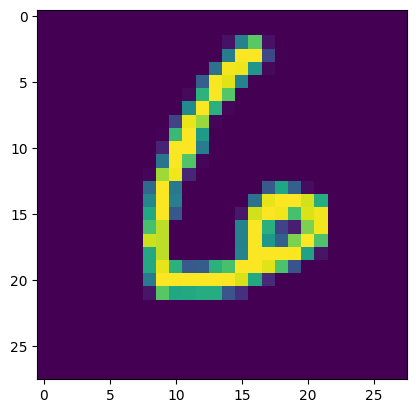

In [678]:
display_image_prediction(2, X_test, y_test_norm, NN)

In [669]:
def show_incorrect(X, y, network):
    output = network.predict(X)
    preds = np.argmax(output, axis=1)
    labels = np.argmax(y, axis=1)
    incorrect = preds != labels
    print(output[2])
    print(preds)
    print(labels)
    return np.where(incorrect == True)

In [670]:
show_incorrect(X_test, y_test, NN)

[[5.10517149e-15]
 [2.96152294e-17]
 [4.61205968e-22]
 [2.63050591e-22]
 [7.31179957e-15]
 [8.92613051e-22]
 [9.33847703e-17]
 [1.82386124e-24]
 [1.25836668e-19]
 [3.45910884e-17]]
[[3]
 [8]
 [4]
 ...
 [4]
 [5]
 [6]]
[[3]
 [8]
 [6]
 ...
 [4]
 [5]
 [6]]


(array([    2,     4,     5, ..., 19982, 19985, 19986]),
 array([0, 0, 0, ..., 0, 0, 0]))